In [383]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit
import scipy.constants as pc
import astropy.units as u
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.table import Table, vstack, join
from scipy.stats import ttest_rel
import csv
from decimal import Decimal
from IPython.display import display, Math
import math

In [384]:
def straight_line(x, m, c):
   
    y=m*x + c
   
    return y

In [385]:
def red_chi_squared(y_values, y_uncertainties, model_data, dof):

  chi_squared = np.sum(((model_data - y_values) / y_uncertainties)**2)

  red_chi = chi_squared / (len(y_values) - dof)

  return red_chi

In [386]:
def weighted_reduced_chi_squared(y_obs, y_err_low, y_err_high, y_model, n_params):
    """
    Calculate the reduced chi-squared for data with asymmetric uncertainties.

    Parameters
    ----------
    y_obs : array_like
        Observed y values.
    y_model : array_like
        Model predictions.
    y_err_low : array_like
        Lower (negative) uncertainties on y.
    y_err_high : array_like
        Upper (positive) uncertainties on y.
    n_params : int
        Number of fitted parameters.

    Returns
    -------
    chi2_red : float
        Reduced chi-squared.
    """

    y_obs = np.asarray(y_obs)
    y_model = np.asarray(y_model)
    y_err_low = np.asarray(y_err_low)
    y_err_high = np.asarray(y_err_high)

    # Use the appropriate uncertainty depending on which side of the data
    sigma = np.where(y_model > y_obs, y_err_high, y_err_low)

    chi2 = np.sum(((y_obs - y_model) / sigma) ** 2)

    dof = len(y_obs) - n_params
    if dof <= 0:
        raise ValueError("Degrees of freedom must be positive.")

    chi2_red = chi2 / dof

    return chi2_red

In [387]:
def calculate_nmad(y, err_high, err_low, y_model):
    """
    Calculates the residuals between linear model and observed data.
    Normalises residuals by error.
    Calculates NMAD.
    """
    residuals = y - y_model

    sigma = np.where(
        residuals > 0,
        err_low,   # data lie above model
        err_high   # data lie below model
    )

    normalised_residuals = residuals / sigma

    nmad = 1.4826 * np.median( np.abs( normalised_residuals - np.median(normalised_residuals) ) )
    return nmad

In [388]:
def uncertainty_propagation(parameters, equation, n_samples=2000, batch_size=500):
    """
    Bootstrap-based uncertainty propagation.

    Parameters
    ----------
    parameters : list of tuples
        Each element is (Q16, Q50, Q84) for a parameter.
    equation : callable
        Function that accepts arrays of sampled parameters.
    n_samples : int
        Number of Monte Carlo samples.
    batch_size : int
        Number of samples to evaluate at once.

    Returns
    -------
    med : float
        Median of propagated quantity.
    upper_err : float
        +1 sigma (84th - median)
    lower_err : float
        -1 sigma (median - 16th)
    """

    samples = []
    # Stores Monte Carlo samples for each parameter

    # Bootstrap each parameter from its empirical percentiles
    for (q16, q50, q84) in parameters:

        # construct empirical distribution (no shape assumptions)
        x = np.array([q16, q50, q84]) # what the percentile values are
        p = np.array([0.16, 0.50, 0.84]) # defines the values as the percentiles we know them to be

        # bootstrap sampling via inverse CDF interpolation
        u = np.random.rand(n_samples) # Random percentiles of 0s and 1s
        s = np.interp(u, p, x) # Takes random percentile and interpolates with known quantities and returns the interpolated value

        samples.append(s)

    # shape: (n_params, n_samples)
    samples = np.array(samples) # converts list into array

    # transpose → (n_samples, n_params)
    samples = samples.T # now each row is (param1_i, param2_i,...)

    # Evaluate model in batches
    values = []

    for start in range(0, n_samples, batch_size):

        stop = min(start + batch_size, n_samples)

        batch_samples = samples[start:stop]

        batch_values = equation(batch_samples) # rows of output_i = equation(param1_i, param2_i,...)

        values.append(batch_values)

    values = np.concatenate(values)

    # Return percentiles
    med = np.percentile(values, 50)
    low = np.percentile(values, 16)
    high = np.percentile(values, 84)

    # RMS scatter of the Monte Carlo distribution
    scatter = np.std(values, ddof=1)

    return med, high - med, med - low

In [389]:
def plot_best_fit_with_uncertainty(ax, x, gradient, intercept,
                              gradient_uncertainty,
                              intercept_uncertainty,
                              label,
                              colour,
                              fill,
                              zorder,
                              line_kwargs=None,
                              band_kwargs=None,
                              ):
    """
    Plot a best-fit line and a shaded uncertainty region.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis to plot on.
    x : array-like
        x-data (used to determine plotting range).
    gradient : float
        Best-fit slope.
    intercept : float
        Best-fit intercept.
    gradient_uncertainty : float
        1-sigma uncertainty on slope.
    intercept_uncertainty : float
        1-sigma uncertainty on intercept.
    label : str
        Label for the fit.
    colour : str
        Colour of the line.
    zorder : float
        Order of when to plot the lines.
    fill : boolean
        True or False depending on if you want upper and lower best fit lines.
    """

    if line_kwargs is None:
        line_kwargs = {"color": colour, "lw": 2}

    if band_kwargs is None:
        band_kwargs = {"color": colour, "alpha": 0.1}

    # Smooth x values for plotting
    x_plot = np.linspace(np.min(x)*0.99, np.max(x)*1.01, 500)

    # Best-fit line
    y = gradient * x_plot + intercept

    # Upper and lower bounds
    y_upper = ((gradient + gradient_uncertainty) * x_plot
               + (intercept + intercept_uncertainty))

    y_lower = ((gradient - gradient_uncertainty) * x_plot
               + (intercept - intercept_uncertainty))

    ax.plot(x_plot, y, **line_kwargs, label=label,zorder=zorder)

    if fill == True:
        ax.fill_between(x_plot, y_lower, y_upper, **band_kwargs)
    ax.legend()

In [390]:
def fit_straight_line_and_plot(x, x_upper_err, x_lower_err, y, y_upper_err, y_lower_err, plot_colours, plot_linear, fill):
    """
    Calculates linear best fit line and plots using plot_best_fit_with_uncertainty()
    """
    popt, pcov = curve_fit(straight_line, x, y, p0=None)

    gradient = popt[0]
    intercept = popt[1]

    gradient_uncertainty = np.sqrt(np.diag(pcov))[0]
    intercept_uncertainty = np.sqrt(np.diag(pcov))[1]

    x_dummy_data = np.linspace(np.min(x),np.max(x),500)

    weighted_red_chi = weighted_reduced_chi_squared(y, y_lower_err, y_upper_err, straight_line(x, gradient, intercept),2)

    scatter = calculate_nmad(y, y_upper_err, y_lower_err, straight_line(x, gradient, intercept))

    fig, ax = plt.subplots(figsize=(10, 10))
    
    ax.errorbar(
        x,
        y,
        xerr = [x_lower_err, x_upper_err],
        yerr=[y_lower_err, y_upper_err],
        fmt='none',
        alpha=0.15,
        lw=0.8,
        zorder=2
    )
    # I've plotted the errorbars separate to the plot to make them more transparent than the points
    ax.scatter(
        x,
        y,
        s=20,
        color=plot_colours,
        zorder=3
    )
    
    if plot_linear == True:
        plot_best_fit_with_uncertainty(ax, x_dummy_data, gradient, intercept, gradient_uncertainty, intercept_uncertainty, "Line of best fit", "red", fill, zorder=1)

    print("")
    print("For plot below: ")

    print(f"Reduced chi squared = {weighted_red_chi:.3g}")
    print(f"Scatter (NMAD of normalised residuals) = {scatter:.3f}")

    # t, p = ttest_rel(x, y)
    # print("p value = ",p)

    return ax, x_dummy_data, gradient, gradient_uncertainty, intercept, intercept_uncertainty, weighted_red_chi



In [391]:

def format_value_uncertainty(value, uncertainty):
    """
    Format a value ± uncertainty using standard significant-figure rules.
    """
    if uncertainty == 0:
        return f"{value:.3f}", "0"

    # 1 significant figure (2 if first digit is 1 or 2)
    exponent = math.floor(math.log10(abs(uncertainty)))
    first_digit = int(abs(uncertainty) / 10**exponent)

    sig_figs = 2 if first_digit in [1, 2] else 1

    decimals = -(exponent - (sig_figs - 1))

    value_rounded = round(value, decimals)
    uncertainty_rounded = round(uncertainty, decimals)

    fmt = f"{{:.{max(decimals,0)}f}}"

    return fmt.format(value_rounded), fmt.format(uncertainty_rounded)

In [392]:
def open_fits_table(file_path):
        # Open the FITS file
        with fits.open(file_path) as hdul:
            # Show the HDU structure
            hdul.info()

            # Usually the table is in extension 1
            data = hdul[1].data

        # Convert to an Astropy Table
        tbl = Table(data)
        #print("Number of objects = ", len(tbl))
        return tbl


In [393]:
def open_csv_table(path):

    table = Table.read(path, format="csv")
    
    # print("Table headers: ", table.colnames)
    
    """
    stellar_fields = ["ID", "RA","Dec","UV1500Best","StellarMassBest","StellarMassQ50", "StellarMassQ16","StellarMassQ84", "SFR10Best","SFR100Best","ZfinalBest"]
    
    stellar_AGN_fields = ["ID", "RA","Dec","AGNanBest","AGNlumQ50","UV1500AGNBest","UV1500Best","StellarMassBest","StellarMassQ50", "StellarMassQ16","StellarMassQ84", "SFR10Best","SFR100Best","ZfinalBest"]
    
    if path == "/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_astro_cat.csv":
    # Data for stellar only fitting
    # Could probably automate this 
        new_table = table[stellar_fields]
        # Data from fits with just stellar
        
    if path == "/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_fritz_astro_cat.csv":
    # Stellar and AGN fit data   
        new_table = table[stellar_AGN_fields]
    
    """
    return table

In [394]:
def filter_best_DIC(stellar_table, stellar_AGN_table):
    """
    Select the stellar mass from either the stellar-only or stellar+AGN fit
    depending on the DIC comparison.

    Uses the AGN model if:
        DIC_AGN < DIC_stellar - 6

    Returns a table containing the best stellar mass estimates and the model
    selected for each galaxy.
    """

    # Match galaxies by ID
    # Some of the headers are the same across both tables, so to avoid confusion, 
    # uniq_col_name keeps the col_name and appends it with stellar or AGN depending on which table it came from.
    table = join(
        stellar_table,
        stellar_AGN_table,
        keys="ID",
        table_names=["stellar", "AGN"],
        uniq_col_name="{col_name}_{table_name}",
    )

    # Read the relevant columns
    DIC_stellar = np.asarray(table["DIC_stellar"], dtype=float)
    DIC_AGN = np.asarray(table["DIC_AGN"], dtype=float)

    mass_stellar_Q16 = np.asarray(table["StellarMassQ16_stellar"], dtype=float)
    mass_stellar_Q50 = np.asarray(table["StellarMassQ50_stellar"], dtype=float)
    mass_stellar_Q84 = np.asarray(table["StellarMassQ84_stellar"], dtype=float)

    mass_AGN_Q16 = np.asarray(table["StellarMassQ16_AGN"], dtype=float)
    mass_AGN_Q50 = np.asarray(table["StellarMassQ50_AGN"], dtype=float)
    mass_AGN_Q84 = np.asarray(table["StellarMassQ84_AGN"], dtype=float)

    # Decide which model to use
    use_AGN = np.zeros(len(table), dtype=bool)

    mask = ~np.isnan(DIC_stellar) & ~np.isnan(DIC_AGN)
    use_AGN[mask] = DIC_AGN[mask] < (DIC_stellar[mask] - 6)

    # If only AGN exists, use it
    use_AGN[np.isnan(DIC_stellar) & ~np.isnan(DIC_AGN)] = True

    # Select best masses
    best_mass_Q16 = np.where(use_AGN, mass_AGN_Q16, mass_stellar_Q16)
    best_mass_Q50 = np.where(use_AGN, mass_AGN_Q50, mass_stellar_Q50)
    best_mass_Q84 = np.where(use_AGN, mass_AGN_Q84, mass_stellar_Q84)
    best_model = np.where(use_AGN, "stellar_AGN", "stellar")

    table["Best_StellarMassQ16"] = best_mass_Q16
    table["Best_StellarMassQ50"] = best_mass_Q50
    table["Best_StellarMassQ84"] = best_mass_Q84
    table["Best_Model"] = best_model

    print("DIC filtered table names: ",table.colnames)
    
    return table

In [395]:
def plot_stellar_masses(combined_table):
    """
    Plotting Q50 stellar mass from stars only against Q50 mass from stars and AGN.
    """
    stellar_only_q16 = combined_table["StellarMassQ16_stellar"].data
    stellar_only_q50 = combined_table["StellarMassQ50_stellar"].data
    stellar_only_q84 = combined_table["StellarMassQ84_stellar"].data
    stellar_AGN_q16 = combined_table["StellarMassQ16_AGN"].data
    stellar_AGN_q50 = combined_table["StellarMassQ50_AGN"].data
    stellar_AGN_q84 = combined_table["StellarMassQ84_AGN"].data


    # Convert quantiles into asymmetric error bars
    yerr = [
        np.log10(stellar_only_q50) - np.log10(stellar_only_q16),
        np.log10(stellar_only_q84) - np.log10(stellar_only_q50)
    ]
    xerr = [
        np.log10(stellar_AGN_q50) - np.log10(stellar_AGN_q16),
        np.log10(stellar_AGN_q84) - np.log10(stellar_AGN_q50)
    ]

    t, p = ttest_rel(stellar_only_q50, stellar_AGN_q50)
    print("p value = ",p)

    fig, ax = plt.subplots(figsize=(10, 10))
    
    ax.errorbar(
        np.log10(stellar_AGN_q50),
        np.log10(stellar_only_q50),
        xerr=xerr,
        yerr=yerr,
        fmt='o',
        ms=4,
        alpha=0.7,
        capsize=2
    )
    
    # 1:1 line
    mmin = min(np.min(np.log10(stellar_AGN_q50)),np.min(np.log10(stellar_only_q50)))
    mmax = max(np.max(np.log10(stellar_AGN_q50)),np.max(np.log10(stellar_only_q50)))

    ax.plot([mmin, mmax], [mmin, mmax], 'k--', lw=1, label='1:1')

    ax.set_ylabel(r'$\log_{10}(M_\star/M_\odot)$ (Stars only)',fontdict={'fontsize': 15})
    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stars + AGN)',fontdict={'fontsize': 15})
    ax.set_ylim(mmin, mmax)
    ax.set_xlim(mmin, mmax)
    ax.set_aspect('equal')
    ax.legend()

    plt.tight_layout()
    plt.show()
    
    return

In [396]:
def check_Q50_mass_against_best(mass_Q16, mass_Q50, mass_Q84, mass_best):
    """
    Plotting stellar mass Q50 and errors (y-axis) against stellar mass best (x-axis).
    Will be done for stellar only data and stellar+AGN data when called separately.
    """
    
    # Convert quantiles into asymmetric error bars
    yerr = [
        np.log10(mass_Q50) - np.log10(mass_Q16),
        np.log10(mass_Q84) - np.log10(mass_Q50)]

    t, p = ttest_rel(mass_best, mass_Q50)
    print("p value = ",p)

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.errorbar(
        np.log10(mass_best),
        np.log10(mass_Q50),
        yerr=yerr,
        fmt='o',
        ms=4,
        alpha=0.7,
        capsize=2
    )
    
    # 1:1 line
    mmin = min(np.min(np.log10(mass_best)),np.min(np.log10(mass_Q50)))
    mmax = max(np.max(np.log10(mass_best)),np.max(np.log10(mass_Q50)))

    ax.plot([mmin, mmax], [mmin, mmax], 'k--', lw=1, label='1:1')

    ax.set_ylabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar Mass Best)',fontdict={'fontsize': 15})
    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar Mass Q50)',fontdict={'fontsize': 15})
    ax.set_ylim(mmin, mmax)
    ax.set_xlim(mmin, mmax)
    ax.set_aspect('equal')
    ax.legend()

    plt.tight_layout()
    plt.show()

    return

In [397]:
def bhm_vs_sm_plot(table):
    """
    Plots log10(bh mass/ solar mass) against log10(stellar mass/ solar mass) 
    with line of best fit and best fit from Reines and Volonteri.

    Second half of function calculates and returns the log10(bhsmr) (Q16,Q50,Q84) and plots against log10(stellar mass/solar mass).
    """
    #Reines and Volonteri data:
    # Refer to Eq 5 of their paper
    RV_gradient = 1.05
    RV_gradient_uncertainty =0.11
    RV_intercept = 7.45 - RV_gradient*11
    RV_intercept_uncertainty = np.sqrt(0.08**2 + (11*0.11)**2)
    #------------------------------------------------------------------------------------------------------------------------------------------
    # Load data

    stellar_mass_Q16 = table["StellarMassQ16"].data
    stellar_mass_Q50 = table["StellarMassQ50"].data
    stellar_mass_Q84 = table["StellarMassQ84"].data
    
    bh_mass = table["BH_MASS"].data
    bh_mass_lower_err = table["BH_MASS_LOWER_ERR"].data
    bh_mass_upper_err = table["BH_MASS_UPPER_ERR"].data

    log_bh_mass = np.log10(bh_mass)
    log_bh_mass_lower_err = log_bh_mass - np.log10(bh_mass - bh_mass_lower_err)
    log_bh_mass_upper_err = np.log10(bh_mass + bh_mass_upper_err) - log_bh_mass
    #------------------------------------------------------------------------------------------------------------------------------------------

    log_stellar_mass = np.log10(stellar_mass_Q50)
    log_stellar_mass_upper_err = np.log10(stellar_mass_Q84) - log_stellar_mass
    log_stellar_mass_lower_err = log_stellar_mass - np.log10(stellar_mass_Q16)

    ax, x_dummy_data, gradient, gradient_uncertainty, intercept, intercept_uncertainty, weighted_red_chi = \
    fit_straight_line_and_plot(x=log_stellar_mass, x_upper_err=log_stellar_mass_upper_err, x_lower_err=log_stellar_mass_lower_err, 
                               y=log_bh_mass, y_upper_err=log_bh_mass_upper_err, y_lower_err=log_bh_mass_lower_err, 
                               plot_colours='C0', plot_linear=True, fill=True)

    plot_best_fit_with_uncertainty(ax, x_dummy_data, RV_gradient, RV_intercept, RV_gradient_uncertainty, RV_intercept_uncertainty, "Reines & Volonteri", "black", fill=True, zorder=1)

    ax.set_ylabel(r'$\log_{10}(M_{BH}/M_\odot)$ (Black Hole Mass)',fontdict={'fontsize': 15})
    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar Mass Q50)',fontdict={'fontsize': 15})
    plt.xlim(5,12)
    #ax.set_aspect('equal')
    ax.legend()
    plt.show()

    grad, grad_err = format_value_uncertainty(gradient, gradient_uncertainty)
    inter, inter_err = format_value_uncertainty(intercept, intercept_uncertainty)

    print("Line of best fit equation: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\odot)"
        rf" = ({grad} \pm {grad_err})\,"
        rf"\log_{{10}}(M_\star/M_\odot)"
        rf" + ({inter} \pm {inter_err})$"
    ))
    

    RV_grad, RV_grad_err = format_value_uncertainty(RV_gradient, RV_gradient_uncertainty)
    RV_inter, RV_inter_err = format_value_uncertainty(RV_intercept, RV_intercept_uncertainty)
    print("")
    print("Reines & Volonteri equation: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\odot)"
        rf" = ({RV_grad} \pm {RV_grad_err})\,"
        rf"\log_{{10}}(M_\star/M_\odot)"
        rf" + ({RV_inter} \pm {RV_inter_err})$"
    ))

In [398]:
def bhsmr_eq(samples):
    """
    Calculates black hole stellar mass ratio given bh_mass (not logged) and stellar mass, in solar masses.
    """
    bh_mass = samples[:,0]
    stellar_mass = samples[:,1]

    return np.log10(bh_mass / stellar_mass)

In [399]:
def bhsmr_plots(table):
    """
    Calculates and returns the log10(bhsmr) (Q16,Q50,Q84) and plots against log10(stellar mass/solar mass).
    Also plots bhsmr against SFR10 and SFR100.

    Returns table appended with new columns containing bhsmr, bhsmr_upper_err, bhsmr_lower_err.
    """
    #----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # bhsmr vs stellar mass
    # Load data
    bh_mass = table["BH_MASS"].data
    bh_mass_lower_err = table["BH_MASS_LOWER_ERR"].data
    bh_mass_upper_err = table["BH_MASS_UPPER_ERR"].data

    stellar_mass_Q16 = table["StellarMassQ16"].data
    stellar_mass_Q50 = table["StellarMassQ50"].data
    stellar_mass_Q84 = table["StellarMassQ84"].data

    # Calculating bhsmr and errs
    bh_mass_Q16 = np.abs(bh_mass - bh_mass_lower_err) # galaxy 3919 has lower_err bigger than bh_mass
    bh_mass_Q50 = bh_mass
    bh_mass_Q84 = bh_mass + bh_mass_upper_err

    bhsmr = np.empty(len(bh_mass_Q50))
    bhsmr_upper_err = np.empty(len(bh_mass_Q50))
    bhsmr_lower_err = np.empty(len(bh_mass_Q50))

    for i in range(len(bh_mass)):
        bhsmr[i], bhsmr_upper_err[i], bhsmr_lower_err[i] = uncertainty_propagation([[bh_mass_Q16[i], bh_mass_Q50[i], bh_mass_Q84[i]], 
                                                                                    [stellar_mass_Q16[i], stellar_mass_Q50[i], stellar_mass_Q84[i]]], bhsmr_eq)     
    
    # Analysis and plotting
    log_stellar_mass_upper_err = np.log10(stellar_mass_Q84) - np.log10(stellar_mass_Q50)
    log_stellar_mass_lower_err = np.log10(stellar_mass_Q50) - np.log10(stellar_mass_Q16)
    log_stellar_mass = np.log10(stellar_mass_Q50)

    ax, x_dummy_data, gradient, gradient_uncertainty, intercept, intercept_uncertainty, weighted_red_chi = \
    fit_straight_line_and_plot(x=log_stellar_mass, x_upper_err=log_stellar_mass_upper_err, x_lower_err=log_stellar_mass_lower_err, 
                               y=bhsmr, y_upper_err=bhsmr_upper_err, y_lower_err=bhsmr_lower_err,
                                plot_colours='C0', plot_linear=True, fill=True)

    ax.set_ylabel(r'$\log_{10}(M_{BH}/M_\star)$ (Black Hole to Stellar Mass Ratio)',fontdict={'fontsize': 15})
    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar Mass Q50)',fontdict={'fontsize': 15})
    ax.set_xlim(5,12)
    ax.set_ylim(-6,2)
    #ax.set_aspect('equal')
    ax.legend()
    plt.show()

    grad, grad_err = format_value_uncertainty(gradient, gradient_uncertainty)
    inter, inter_err = format_value_uncertainty(intercept, intercept_uncertainty)

    print("Line of best fit equation: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\star)"
        rf" = ({grad} \pm {grad_err})\,"
        rf"\log_{{10}}(M_\star/M_\odot)"
        rf" + ({inter} \pm {inter_err})$"
    ))

    #-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # bhsmr vs SFR10
    # Load data
    sfr10_Q16 = table["SFR10Q16"]
    sfr10_Q50 = table["SFR10Q50"]
    sfr10_Q84 = table["SFR10Q84"]
    # (units of solar masses / yr)

    log_sfr10_lower_err = np.log10(sfr10_Q50) - np.log10(sfr10_Q16)
    log_sfr10_upper_err = np.log10(sfr10_Q84) - np.log10(sfr10_Q50)
    log_sfr10 = np.log10(sfr10_Q50)

    # Analysis and plotting
    # Everything with 10 is relating to SFR10

    def zoom_in_10(zoom):

        ax10, x_dummy_data10, gradient10, gradient_uncertainty10, intercept10, intercept_uncertainty10, weighted_red_chi10 = \
        fit_straight_line_and_plot(x=log_sfr10, x_upper_err=log_sfr10_upper_err, x_lower_err=log_sfr10_lower_err, 
                                   y=bhsmr, y_upper_err=bhsmr_upper_err, y_lower_err=bhsmr_lower_err,
                                    plot_colours='C0', plot_linear=True, fill=True)

        ax10.set_ylabel(r'$\log_{10}(M_{BH}/M_\star)$ (Black Hole to Stellar Mass Ratio)',fontdict={'fontsize': 15})
        ax10.set_xlabel(r'$\log_{10}(SFR10 M_\odot yr^{{-1}})$',fontdict={'fontsize': 15})

        if zoom == True:
                ax10.set_xlim(-5, x_dummy_data10[-1] * 1.05)
                ax10.set_ylim(np.min(bhsmr) * 0.9, np.max(bhsmr) * 1.1)
                ax10.set_title("Zoomed in plot")
        if zoom == False:
            ax10.set_xlim(x_dummy_data10[0] * 0.95, x_dummy_data10[-1] * 1.05)
        
        ax10.legend()
        plt.show()

        grad10, grad_err10 = format_value_uncertainty(gradient10, gradient_uncertainty10)
        inter10, inter_err10 = format_value_uncertainty(intercept10, intercept_uncertainty10)

        print("Line of best fit equation: ")
        display(Math(
            rf"$\log_{{10}}(M_{{\rm BH}}/M_\star)"
            rf" = ({grad10} \pm {grad_err10})\,"
            rf"\log_{{10}}(SFR10 / M_\odot yr^{{-1}})"
            rf" + ({inter10} \pm {inter_err10})$"
        ))
    zoom_in_10(False)
    zoom_in_10(True)
    
    #-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # bhsmr vs SFR100
    # Load data
    sfr100_Q16 = table["SFR10Q16"]
    sfr100_Q50 = table["SFR100Q50"]
    sfr100_Q84 = table["SFR100Q84"]
    # (units of solar masses / yr)

    log_sfr100_lower_err = np.log10(sfr100_Q50) - np.log10(sfr100_Q16)
    log_sfr100_upper_err = np.log10(sfr100_Q84) - np.log10(sfr100_Q50)
    log_sfr100 = np.log10(sfr100_Q50)

    # Analysis and plotting
    # Everything with 100 is relating to SFR100

    def zoom_in_100(zoom):

        ax100, x_dummy_data100, gradient100, gradient_uncertainty100, intercept100, intercept_uncertainty100, weighted_red_chi100 = \
        fit_straight_line_and_plot(x=log_sfr100, x_upper_err=log_sfr100_upper_err, x_lower_err=log_sfr100_lower_err, 
                                   y=bhsmr, y_upper_err=bhsmr_upper_err, y_lower_err=bhsmr_lower_err,
                                   plot_colours='C0', plot_linear=True, fill=True)

        ax100.set_ylabel(r'$\log_{10}(M_{BH}/M_\star)$ (Black Hole to Stellar Mass Ratio)',fontdict={'fontsize': 15})
        ax100.set_xlabel(r'$\log_{10}(SFR100 M_\odot yr^{{-1}})$',fontdict={'fontsize': 15})

        if zoom == True:
            ax100.set_xlim(-5, x_dummy_data100[-1] * 1.05)
            ax100.set_ylim(np.min(bhsmr) * 0.9, np.max(bhsmr) * 1.1)
            ax100.set_title("Zoomed in plot")
        if zoom == False:
            ax100.set_xlim(x_dummy_data100[0] * 0.95, x_dummy_data100[-1] * 1.05)
        
        ax100.legend()
        plt.show()

        grad100, grad_err100 = format_value_uncertainty(gradient100, gradient_uncertainty100)
        inter100, inter_err100 = format_value_uncertainty(intercept100, intercept_uncertainty100)

        print("Line of best fit equation: ")
        display(Math(
            rf"$\log_{{10}}(M_{{\rm BH}}/M_\star)"
            rf" = ({grad100} \pm {grad_err100})\,"
            rf"\log_{{10}}(SFR100 / M_\odot yr^{{-1}})"
            rf" + ({inter100} \pm {inter_err100})$"
        ))
    zoom_in_100(zoom=False)
    zoom_in_100(zoom=True)
    #-----------------------------------------------------------------------------------------------------------------------
    table["bhsmr"] = bhsmr
    table["bhsmr_upper_err"] = bhsmr_upper_err
    table["bhsmr_lower_err"] = bhsmr_lower_err

    return table

In [400]:
def AGNfrac_vs_bhsmr(table):
    """
    Plots AGN fraction from Fritz06 models against bhsmr ratio.
    """
    # Load data
    AGNfrac_Q16 = np.asarray(table["AGN_Dale_fracQ16"].data)
    AGNfrac_Q50 = np.asarray(table["AGN_Dale_fracQ50"].data)
    AGNfrac_Q84 = np.asarray(table["AGN_Dale_fracQ84"].data)

    AGNfrac_lower_err = AGNfrac_Q50 - AGNfrac_Q16
    AGNfrac_upper_err = AGNfrac_Q84 - AGNfrac_Q50

    bhsmr = np.asarray(table["bhsmr"].data)
    bhsmr_upper_err = np.asarray(table["bhsmr_upper_err"].data)
    bhsmr_lower_err = np.asarray(table["bhsmr_lower_err"].data)

    # Plotting
    ax, x_dummy_data, gradient, gradient_uncertainty, intercept, intercept_uncertainty, weighted_red_chi = \
    fit_straight_line_and_plot(x=bhsmr, x_upper_err=bhsmr_upper_err, x_lower_err=bhsmr_lower_err, y=AGNfrac_Q50, y_upper_err=AGNfrac_upper_err, y_lower_err=AGNfrac_lower_err,
                               plot_colours='C0', plot_linear=False, fill=False)

    ax.set_yscale('log')
    ax.set_ylabel(r'$AGN fraction$ (Fraction of flux from AGN over total)',fontdict={'fontsize': 15})
    ax.set_xlabel(r'$\log_{10}(M_{BH}/M_\star)$ (Black Hole Stellar Mass Ratio)',fontdict={'fontsize': 15})
    ax.set_xlim(-6,3)
    ax.legend()
    plt.show()

    grad, grad_err = format_value_uncertainty(gradient, gradient_uncertainty)
    inter, inter_err = format_value_uncertainty(intercept, intercept_uncertainty)

    print("Line of best fit equation: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\star)"
        rf" = ({grad} \pm {grad_err})\,"
        rf"\log_{{10}}(M_\star/M_\odot)"
        rf" + ({inter} \pm {inter_err})$"
    ))

In [401]:
def plot_AGNlum(stellar_table, stellar_AGN_table, galaxy_table):

    """
    Plotting Q50 AGN luminosity against Q50 stellar mass, showing by colour which SED model was selected (stellar only or stellar+AGN).

    Plotting difference between stellar mass from stellar only table and stellar AGN table.

    Plotting AGN luminosity from model against Shay's data.
    """
    DIC_filtered_table = filter_best_DIC(stellar_table, stellar_AGN_table)
    # Makes a combined table of data from both fits and appends new columns with mass_best etc. and the model selected for each galaxy (stellar only or stellar+AGN)

    DIC_filtered_table = join(
        DIC_filtered_table,
        galaxy_table,
        keys="ID"
    )

    #Load data
    stellar_mass_Q16 = DIC_filtered_table["Best_StellarMassQ16"].data
    stellar_mass_Q50 = DIC_filtered_table["Best_StellarMassQ50"].data
    stellar_mass_Q84 = DIC_filtered_table["Best_StellarMassQ84"].data
    model = DIC_filtered_table["Best_Model"].data
    AGNlum_Q16 = DIC_filtered_table["AGNlumQ16"].data
    AGNlum_Q50 = DIC_filtered_table["AGNlumQ50"].data
    AGNlum_Q84 = DIC_filtered_table["AGNlumQ84"].data

    log_stellar_mass_errs = [
        np.log10(stellar_mass_Q50) - np.log10(stellar_mass_Q16),
        np.log10(stellar_mass_Q84) - np.log10(stellar_mass_Q50)]
    
    log_AGNlum_errs = [
        np.log10(AGNlum_Q50) - np.log10(AGNlum_Q16),
        np.log10(AGNlum_Q84) - np.log10(AGNlum_Q50)]
    
    log_AGNlum = np.log10(AGNlum_Q50)
    
    #--------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Making colour plot of model AGNlum against stellar mass
    
    xerr = log_stellar_mass_errs
    yerr = log_AGNlum_errs

    AGN = model == "stellar_AGN"
    stellar = model == "stellar"

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.errorbar(
        np.log10(stellar_mass_Q50[AGN]),
        np.log10(AGNlum_Q50[AGN]),
        xerr=[xerr[0][AGN], xerr[1][AGN]],
        yerr=[yerr[0][AGN], yerr[1][AGN]],
        fmt='None',
        color='red',
        lw=0.8,
        alpha=0.2,
        )

    ax.scatter(
        np.log10(stellar_mass_Q50[AGN]),
        np.log10(AGNlum_Q50[AGN]),
        s=20,
        color='red',
        alpha=0.8,
        label='Stellar + AGN'
        )

    ax.errorbar(
        np.log10(stellar_mass_Q50[stellar]),
        np.log10(AGNlum_Q50[stellar]),
        xerr=[xerr[0][stellar], xerr[1][stellar]],
        yerr=[yerr[0][stellar], yerr[1][stellar]],
        fmt='None',
        color='blue',
        lw=0.8,
        alpha=0.2,
        label='Stellar only'
    )

    ax.scatter(
        np.log10(stellar_mass_Q50[stellar]),
        np.log10(AGNlum_Q50[stellar]),
        s=20,
        color='blue',
        alpha=0.8,
        label='Stellar only'
    )
    ax.legend()

    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar Mass Q50)',fontdict={'fontsize': 15})
    ax.set_ylabel(r'$\log_{10}(L_{\rm AGN}/L_\odot)$ (Model AGN Luminosity Q50)',fontdict={'fontsize': 15})
    ax.set_xlim(0.95 * np.min(np.log10(stellar_mass_Q50)), 1.05 * np.max(np.log10(stellar_mass_Q50)))
    ax.legend(["Stellar + AGN", "Stellar only"])
    plt.show()
    #--------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Plotting difference between stellar mass across both models against model AGNlum to see if fit was necessary
    # Residual = stellar - stellar+AGN because I expect stellar only fit to over estimate M_star

    fwhm = DIC_filtered_table["FWHM"]

    mass_resid = np.log10(DIC_filtered_table["StellarMassQ50_stellar"].data) - np.log10(DIC_filtered_table["StellarMassQ50_AGN"].data)
    #log_mass_resid = np.log10(mass_resid)

    mass_resid_upper_err = np.log10(DIC_filtered_table["StellarMassQ84_stellar"].data) - np.log10(DIC_filtered_table["StellarMassQ16_AGN"].data ) - mass_resid
    mass_resid_lower_err = mass_resid - np.log10( DIC_filtered_table["StellarMassQ16_stellar"].data) - np.log10(DIC_filtered_table["StellarMassQ84_AGN"].data )

    fig, (ax, ax_zoom) = plt.subplots(1, 2, figsize=(20, 10), sharex=True)
    
    colours = np.empty(len(fwhm), dtype=object)
    colours[fwhm < 100] = 'tab:red'
    colours[(fwhm >= 100) & (fwhm < 1000)] = 'tab:orange'
    colours[(fwhm >= 1000)] = 'tab:green'
    
    for axis in (ax, ax_zoom):
        axis.errorbar(
            x=log_AGNlum,
            y=mass_resid,
            xerr=log_AGNlum_errs,
            yerr=[mass_resid_lower_err, mass_resid_upper_err],
            fmt='none',
            alpha=0.15,
            lw=0.8,
            zorder=2
        )
        # I've plotted the errorbars separate to the plot to make them more transparent than the points
        axis.scatter(
            log_AGNlum,
            mass_resid,
            c=colours,
            s=25,
            edgecolors='k',
            linewidths=0.3,
            zorder=3
        )

        axis.axhline(0,color='0.4',lw=0.8,alpha=0.6)

        axis.set_xlabel(r'$\log_{10}(L_{AGN})$ (Fritz06 model AGN Luminosity)',fontdict={'fontsize': 14})

        legend_elements = [
            Line2D([0], [0], marker='o', color='w',
                label='FWHM < 100',
                markerfacecolor='tab:red',
                markeredgecolor='k',
                markersize=7),

            Line2D([0], [0], marker='o', color='w',
                label='100 ≤ FWHM < 1000',
                markerfacecolor='tab:orange',
                markeredgecolor='k',
                markersize=7),

            Line2D([0], [0], marker='o', color='w',
                label='FWHM ≥ 1000',
                markerfacecolor='tab:green',      
                markeredgecolor='k',
                markersize=7)
        ]

        ax.legend(handles=legend_elements, title='FWHM')

    ax.set_ylabel(r'$\Delta log_{10}(M_\star/M_\odot)$ (Stellar Mass log10 difference between stellar only and stellar+AGN model Q50)',fontdict={'fontsize': 14})

    # Limits
    xmin = 0.99 * log_AGNlum.min()
    xmax = 1.01 * log_AGNlum.max()

    ax.set_xlim(xmin, xmax)

    ax_zoom.set_ylim(-1, 6)

    plt.tight_layout()
    plt.show()
    """
    grad_r, grad_err_r = format_value_uncertainty(gradient_r, gradient_uncertainty_r)
    inter_r, inter_err_r = format_value_uncertainty(intercept_r, intercept_uncertainty_r)

    print("Line of best fit equation: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\star)"
        rf" = ({grad_r} \pm {grad_err_r})\,"
        rf"\log_{{10}}(SFR100 / M_\odot yr^{{-1}})"
        rf" + ({inter_r} \pm {inter_err_r})$"
    ))
    """

    #--------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Plotting model AGNlum against lum from data   
    # Variables ending in 2 refer to this 2nd plot

    #Load data
    L_bol = DIC_filtered_table["L_BH_BOL"].data
    L_upper_err = DIC_filtered_table["L_BH_BOL_UPPER_ERR"].data
    L_lower_err = DIC_filtered_table["L_BH_BOL_LOWER_ERR"].data

    log_L_upper_err = np.log10(L_bol + L_upper_err) - np.log10(L_bol)
    log_L_lower_err = np.log10(L_bol) - np.log10(L_bol - L_lower_err)
    log_L_bol = np.log10(L_bol)

    ax2, x_dummy_data2, gradient2, gradient_uncertainty2, intercept2, intercept_uncertainty2, weighted_red_chi2 = \
    fit_straight_line_and_plot(x=log_L_bol, x_upper_err=log_L_upper_err, x_lower_err=log_L_lower_err, 
                               y=log_AGNlum, y_upper_err=log_AGNlum_errs[1], y_lower_err=log_AGNlum_errs[0],
                                plot_colours='C0', plot_linear=True, fill=False)

    # 1:1 line
    mmin = min(np.min(log_L_bol),np.min(log_AGNlum))
    mmax = max(np.max(log_L_bol),np.max(log_AGNlum))

    ax2.plot([mmin, mmax], [mmin, mmax], 'k--', lw=1, label='1:1')

    ax2.set_ylabel(r'$\log_{10}(L_{AGN})$ (Fritz06 model AGN Luminosity)',fontdict={'fontsize': 15})
    ax2.set_xlabel(r'$\log_{10}(L_{H\alpha,bol})$ (Observed AGN luminosity)',fontdict={'fontsize': 15})
    plt.xlim(0.95 * x_dummy_data2[0],1.05 * x_dummy_data2[-1])
    #ax.set_aspect('equal')
    ax2.legend()
    plt.show()

    grad2, grad_err2 = format_value_uncertainty(gradient2, gradient_uncertainty2)
    inter2, inter_err2 = format_value_uncertainty(intercept2, intercept_uncertainty2)

    print("Line of best fit equation: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\star)"
        rf" = ({grad2} \pm {grad_err2})\,"
        rf"\log_{{10}}(SFR100 / M_\odot yr^{{-1}})"
        rf" + ({inter2} \pm {inter_err2})$"
    ))

In [402]:
def sSFR_eq(samples):

    sfr = samples[:,0]
    stellar_mass = samples[:,1]

    sSFR = sfr / stellar_mass
    return sSFR

In [403]:
def sSFR_vs_M(ProSpect_table):
    """
    SFR / stellar mass against stellar mass, for SFR10 and SFR100.
    """

    # Load data
    stellar_mass_Q16 = ProSpect_table["StellarMassQ16"].data
    stellar_mass_Q50 = ProSpect_table["StellarMassQ50"].data
    stellar_mass_Q84 = ProSpect_table["StellarMassQ84"].data

    log_stellar_mass_upper_err = np.log10(stellar_mass_Q84) - np.log10(stellar_mass_Q50)
    log_stellar_mass_lower_err = np.log10(stellar_mass_Q50) - np.log10(stellar_mass_Q16)
    log_stellar_mass = np.log10(stellar_mass_Q50)

    sfr10_Q50 = ProSpect_table["SFR10Q50"].data
    sfr10_Q16 = ProSpect_table["SFR10Q16"].data
    sfr10_Q84 = ProSpect_table["SFR10Q84"].data

    sfr100_Q50 = ProSpect_table["SFR100Q50"].data
    sfr100_Q16 = ProSpect_table["SFR100Q16"].data
    sfr100_Q84 = ProSpect_table["SFR100Q84"].data    

    #-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # sSFR10 vs stellar mass plot
    # Calculating SFR10
    sSFR10 = np.empty(len(sfr10_Q50))
    sSFR10_upper_err = np.empty(len(sfr10_Q50))
    sSFR10_lower_err = np.empty(len(sfr10_Q50))

    for i in range(len(sfr10_Q50)):
        sSFR10[i], sSFR10_upper_err[i], sSFR10_lower_err[i] = uncertainty_propagation([[sfr10_Q16[i], sfr10_Q50[i], sfr10_Q84[i]], 
                                                                                    [stellar_mass_Q16[i], stellar_mass_Q50[i], stellar_mass_Q84[i]]], sSFR_eq)    

    log_sSFR10 = np.log10(sSFR10)
    log_sSFR10_upper_err = np.log10(sSFR10_upper_err)
    log_sSFR10_lower_err = np.log10(sSFR10_lower_err) 

    # Analysis and plotting

    def zoom10(zoom):
        ax10, x_dummy10, gradient10, gradient_uncertainty10, intercept10, intercept_uncertainty10, weighted_red_chi10 = \
        fit_straight_line_and_plot(x=log_stellar_mass, x_upper_err=log_stellar_mass_upper_err, x_lower_err=log_stellar_mass_lower_err, 
                                   y=log_sSFR10, y_upper_err=log_sSFR10_upper_err, y_lower_err=log_sSFR10_lower_err,
                                   plot_colours='C0', plot_linear=True, fill=True)

        ax10.set_ylabel(r'$\log_{10}(sSFR10 / yr^{-1})$',fontdict={'fontsize': 15})
        ax10.set_xlabel(r'$\log_{10}(M_\star / M\odot$)',fontdict={'fontsize': 15})
        plt.xlim(5,12)
        if zoom == True:
            
            plt.ylim(-18,1)
            plt.title("Zoomed in plot of above")
            ax10.legend()
            plt.show()

        if zoom == False:
            ax10.legend()
            plt.show()
        
            grad10, grad_err10 = format_value_uncertainty(gradient10, gradient_uncertainty10)
            inter10, inter_err10 = format_value_uncertainty(intercept10, intercept_uncertainty10)

            print("Line of best fit equation: ")
            display(Math(
                rf"$\log_{{10}}(sSFR10/yr^{{-1}})"
                rf" = ({grad10} \pm {grad_err10})\,"
                rf"\log_{{10}}(M_\star/M_\odot)"
                rf" + ({inter10} \pm {inter_err10})$"
            ))
    zoom10(False)
    zoom10(True)

    #-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # sSFR100 vs stellar mass plot
    # Calculating SFR10
    sSFR100 = np.empty(len(sfr100_Q50))
    sSFR100_upper_err = np.empty(len(sfr100_Q50))
    sSFR100_lower_err = np.empty(len(sfr100_Q50))

    for i in range(len(sfr100_Q50)):
        sSFR100[i], sSFR100_upper_err[i], sSFR100_lower_err[i] = uncertainty_propagation([[sfr100_Q16[i], sfr100_Q50[i], sfr100_Q84[i]], 
                                                                                    [stellar_mass_Q16[i], stellar_mass_Q50[i], stellar_mass_Q84[i]]], sSFR_eq)    

    log_sSFR100 = np.log10(sSFR100)
    log_sSFR100_upper_err = np.log10(sSFR100_upper_err)
    log_sSFR100_lower_err = np.log10(sSFR100_lower_err) 

    # Analysis and plotting

    def zoom100(zoom):
        ax100, x_dummy100, gradient100, gradient_uncertainty100, intercept100, intercept_uncertainty100, weighted_red_chi100 = \
        fit_straight_line_and_plot(x=log_stellar_mass, x_upper_err=log_stellar_mass_upper_err, x_lower_err=log_stellar_mass_lower_err, 
                                   y=log_sSFR100, y_upper_err=log_sSFR100_upper_err, y_lower_err=log_sSFR100_lower_err, 
                                   plot_colours='C0', plot_linear=True, fill=True)

        ax100.set_ylabel(r'$\log_{10}(sSFR100 / yr^{-1})$',fontdict={'fontsize': 15})
        ax100.set_xlabel(r'$\log_{10}(M_\star / M\odot$)',fontdict={'fontsize': 15})
        plt.xlim(5,12)
        if zoom == True:
            plt.ylim(-15,-6)
        
            ax100.legend()
            plt.show()

        if zoom == False:
            ax100.legend()
            plt.show()
        
            grad100, grad_err100 = format_value_uncertainty(gradient100, gradient_uncertainty100)
            inter100, inter_err100 = format_value_uncertainty(intercept100, intercept_uncertainty100)

            print("Line of best fit equation: ")
            display(Math(
                rf"$\log_{{10}}(sSFR100/yr^{{-1}})"
                rf" = ({grad100} \pm {grad_err100})\,"
                rf"\log_{{10}}(M_\star/M_\odot)"
                rf" + ({inter100} \pm {inter_err100})$"
            ))
    zoom100(False)
    zoom100(True)

    return sSFR10, sSFR10_upper_err, sSFR10_lower_err, sSFR100, sSFR100_upper_err, sSFR100_lower_err


In [404]:
def edd_ratio_vs_bh_m(table):
    """
    Plots Eddington ratio against black hole mass.
    """
    #Load data
    edd_ratio = np.asarray(table["EDD_RATIO"], dtype="float")
    edd_ratio_upper_err = np.asarray(table["EDD_RATIO_UPPER_ERR"], dtype="float")
    edd_ratio_lower_err = np.asarray(table["EDD_RATIO_LOWER_ERR"], dtype="float")

    bh_mass = table["BH_MASS"].data
    bh_mass_lower_err = table["BH_MASS_LOWER_ERR"].data
    bh_mass_upper_err = table["BH_MASS_UPPER_ERR"].data

    log_bh_mass = np.log10(bh_mass)
    log_bh_mass_lower_err = log_bh_mass - np.log10(bh_mass - bh_mass_lower_err)
    log_bh_mass_upper_err = np.log10(bh_mass + bh_mass_upper_err) - log_bh_mass

    fwhm = np.asarray(table["FWHM"], dtype="float")
    #------------------------------------------------------------------------------------------------------------------------
    # Colours for plotting
    colours = np.empty(len(fwhm), dtype=object)
    colours[fwhm < 100] = 'tab:red'
    colours[(fwhm >= 100) & (fwhm < 1000)] = 'tab:orange'
    colours[(fwhm >= 1000)] = 'tab:green'

    legend_elements = [
            Line2D([0], [0], marker='o', color='w',
                label='FWHM < 100',
                markerfacecolor='tab:red',
                markeredgecolor='k',
                markersize=7),

            Line2D([0], [0], marker='o', color='w',
                label='100 ≤ FWHM < 1000',
                markerfacecolor='tab:orange',
                markeredgecolor='k',
                markersize=7),

            Line2D([0], [0], marker='o', color='w',
                label='FWHM ≥ 1000',
                markerfacecolor='tab:green',      
                markeredgecolor='k',
                markersize=7)
        ]
    #------------------------------------------------------------------------------------------------------------------------

    ax, x_dummy_data, gradient, gradient_uncertainty, intercept, intercept_uncertainty, weighted_red_chi = \
    fit_straight_line_and_plot(x=log_bh_mass, x_upper_err=log_bh_mass_upper_err, x_lower_err=log_bh_mass_lower_err, 
                               y=edd_ratio, y_upper_err=edd_ratio_upper_err, y_lower_err=edd_ratio_lower_err,
                               plot_colours=colours, plot_linear=True, fill=True)
    
    ax.set_ylabel(r'$L_{AGN}/L_{Edd}$ (Eddington ratio)',fontdict={'fontsize': 15})
    ax.set_xlabel(r'$\log_{10}(M_{BH}/M_\odot)$ (Black Hole Mass)',fontdict={'fontsize': 15})
    ax.axhline(0,color='0.4',lw=0.8,alpha=0.6)
    plt.ylim(-1, 30)
    ax.legend(handles=legend_elements, title='FWHM')
    plt.show()

    grad, grad_err = format_value_uncertainty(gradient, gradient_uncertainty)
    inter, inter_err = format_value_uncertainty(intercept, intercept_uncertainty)

    print("Line of best fit equation: ")
    display(Math(
        rf"$L_{{AGN}}/L_{{Edd}}"
        rf" = ({grad} \pm {grad_err})\,"
        rf"\log_{{10}}(M_{{BH}}/M_\odot)"
        rf" + ({inter} \pm {inter_err})$"
    ))
    

Filename: /nvme/scratch/work/alberttg/Summer_project/Ha_and_NII_broad_line_data.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    162   144R x 77C   [D, E, E, E, E, E, E, E, E, 5A, D, D, D, E, E, E, E, E, E, E, E, D, D, D, D, D, D, D, D, D, E, E, E, E, E, E, E, E, D, D, D, D, D, D, D, D, E, E, E, E, E, E, E, E, D, D, D, D, D, D, 18A, 21A, J, E, E, E, E, E, E, E, E, D, D, D, D, D, D]   


p value =  0.02442985722286986


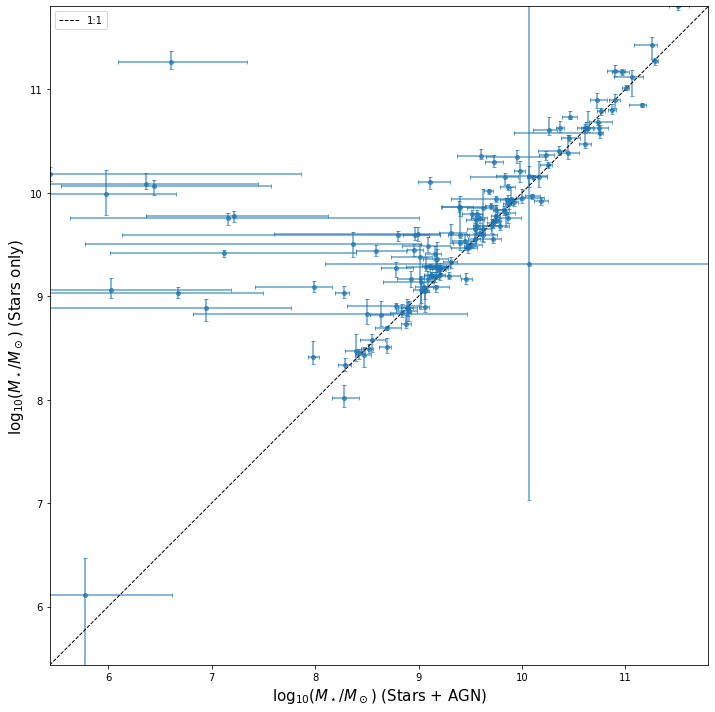

DIC filtered table names:  ['mSFRBest_stellar', 'mpeakBest_stellar', 'mperiodBest_stellar', 'mskewBest_stellar', 'tau_birthBest_stellar', 'tau_screenBest_stellar', 'alpha_SF_birthBest_stellar', 'alpha_SF_screenBest_stellar', 'ZfinalBest_stellar', 'StellarMassBest_stellar', 'SFR10Best_stellar', 'SFR100Best_stellar', 'UV1500Best_stellar', 'UV1500AGNBest_stellar', 'DustLumBirthBest_stellar', 'DustLumScreenBest_stellar', 'DustLumTotalBest_stellar', 'DustMassBirthBest_stellar', 'DustMassScreenBest_stellar', 'DustMassTotalBest_stellar', 'NgasMassBirthBest_stellar', 'NgasMassScreenBest_stellar', 'NgasMassTotalBest_stellar', 'LPBest_stellar', 'F606W_fit_fluxBest_stellar', 'F814W_fit_fluxBest_stellar', 'F115W_fit_fluxBest_stellar', 'F150W_fit_fluxBest_stellar', 'F200W_fit_fluxBest_stellar', 'F277W_fit_fluxBest_stellar', 'F356W_fit_fluxBest_stellar', 'F444W_fit_fluxBest_stellar', 'F606W_fit_AGN_fluxBest_stellar', 'F814W_fit_AGN_fluxBest_stellar', 'F115W_fit_AGN_fluxBest_stellar', 'F150W_fit_AGN_

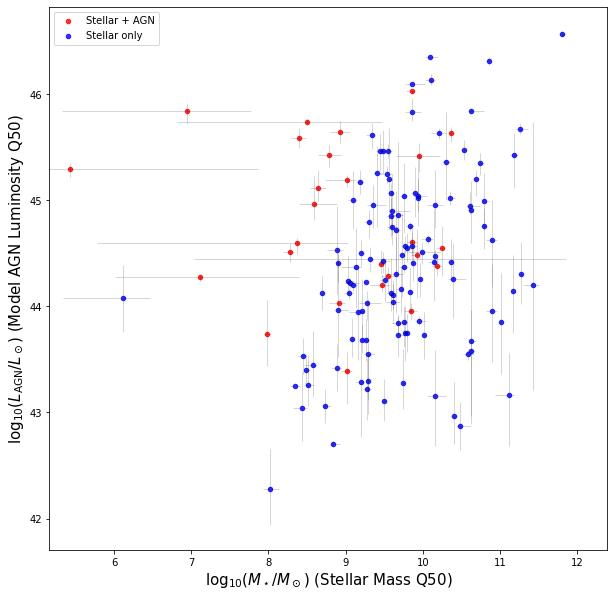

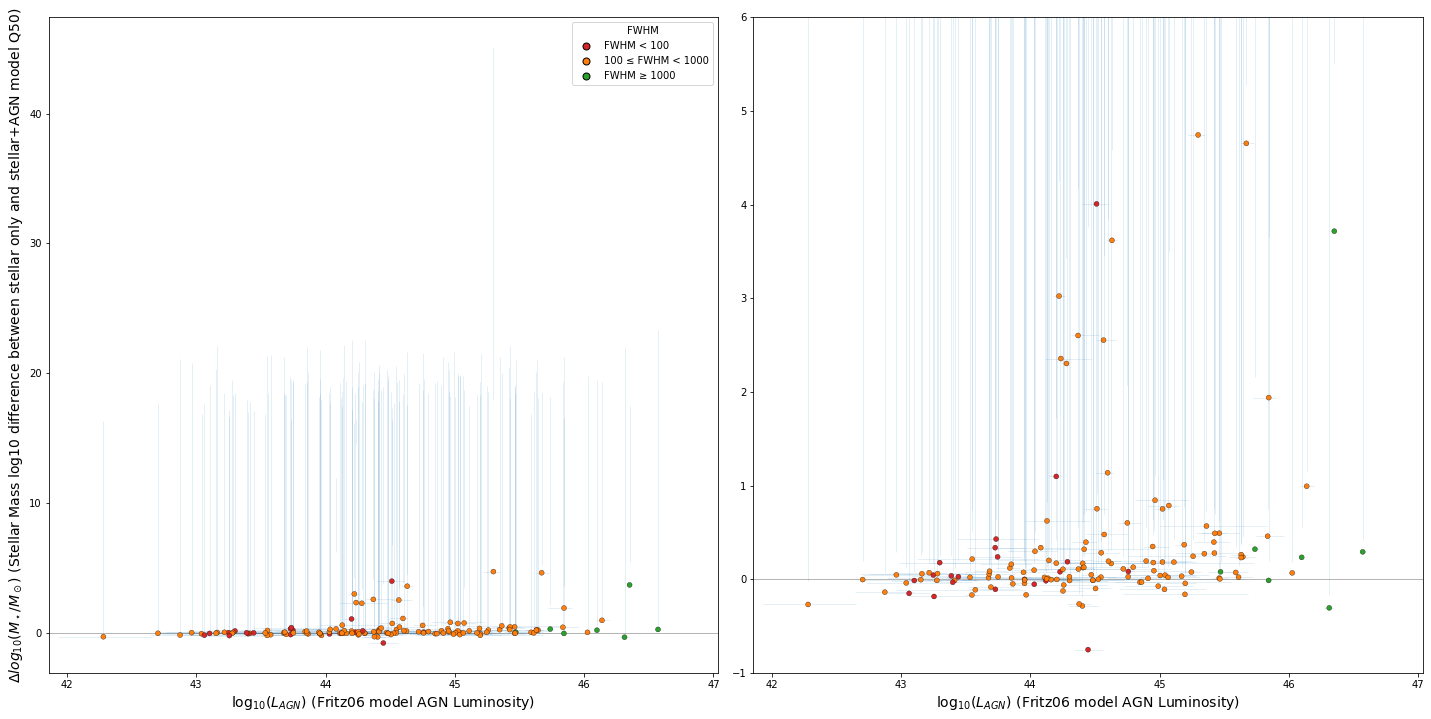


For plot below: 
Reduced chi squared = 61.6
Scatter (NMAD of normalised residuals) = 0.707


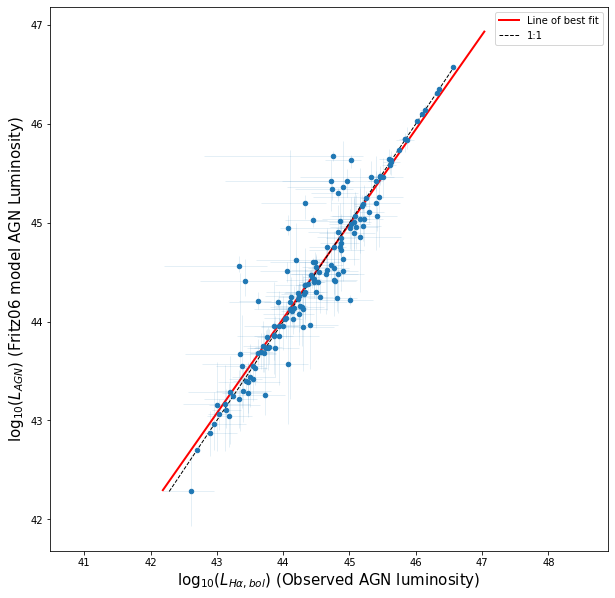

Line of best fit equation: 


<IPython.core.display.Math object>


Plot of black hole mass against stellar mass from SED fit of stellar light only

For plot below: 
Reduced chi squared = 3.91e+04
Scatter (NMAD of normalised residuals) = 7.801


/usr/local/anaconda-python-3.6/lib/python3.6/site-packages/ipykernel_launcher.py:26: RuntimeWarning: invalid value encountered in log10


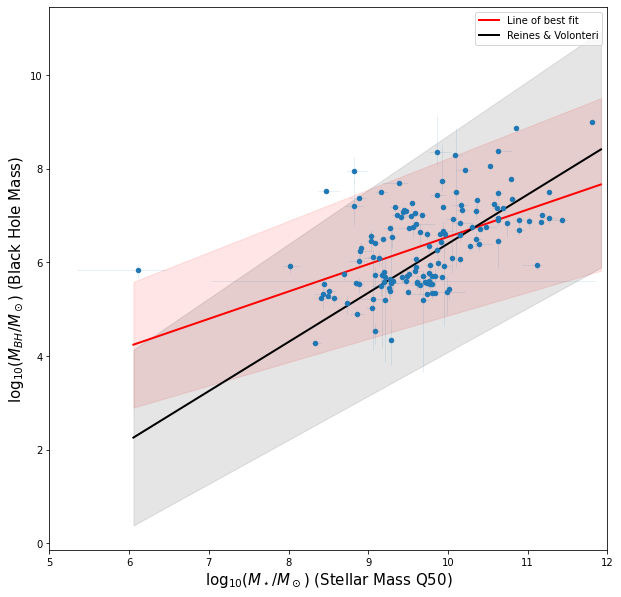

Line of best fit equation: 


<IPython.core.display.Math object>


Reines & Volonteri equation: 


<IPython.core.display.Math object>


For plot below: 
Reduced chi squared = 131
Scatter (NMAD of normalised residuals) = 6.492


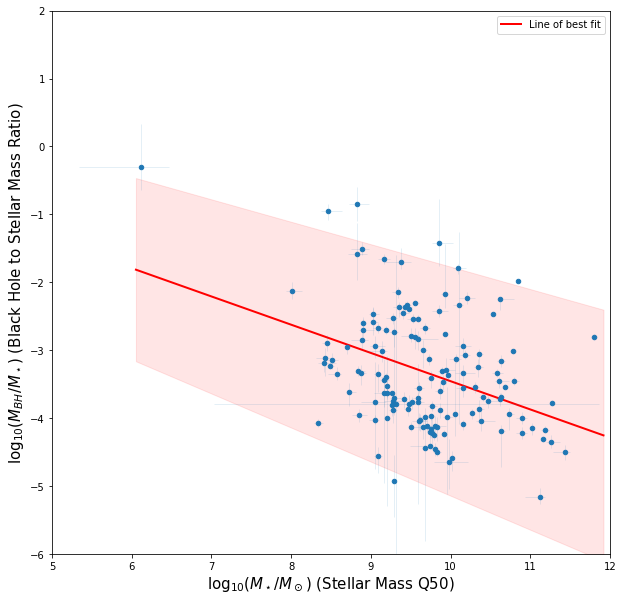

Line of best fit equation: 


<IPython.core.display.Math object>


For plot below: 
Reduced chi squared = 105
Scatter (NMAD of normalised residuals) = 6.961


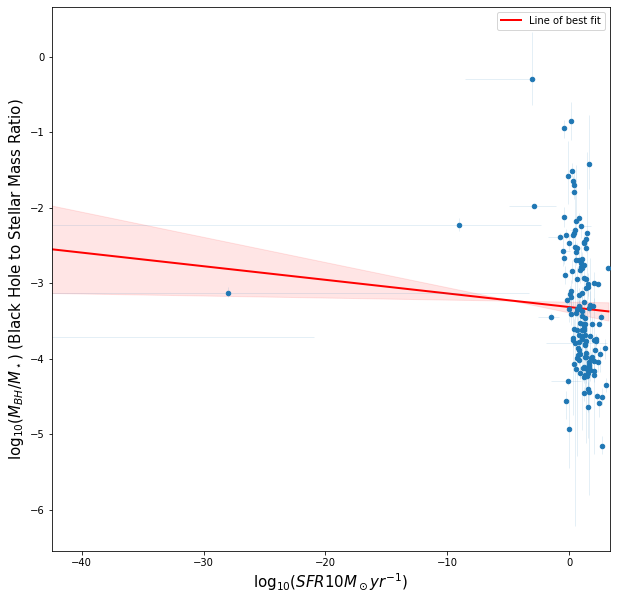

Line of best fit equation: 


<IPython.core.display.Math object>


For plot below: 
Reduced chi squared = 105
Scatter (NMAD of normalised residuals) = 6.961


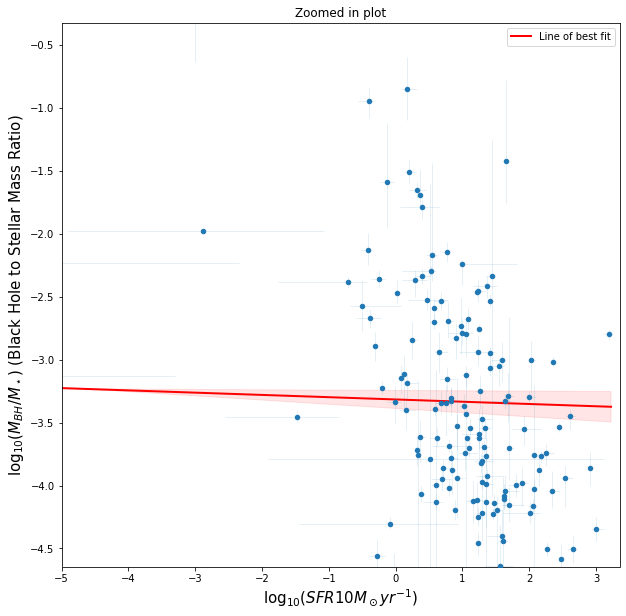

Line of best fit equation: 


<IPython.core.display.Math object>


For plot below: 
Reduced chi squared = 105
Scatter (NMAD of normalised residuals) = 6.901


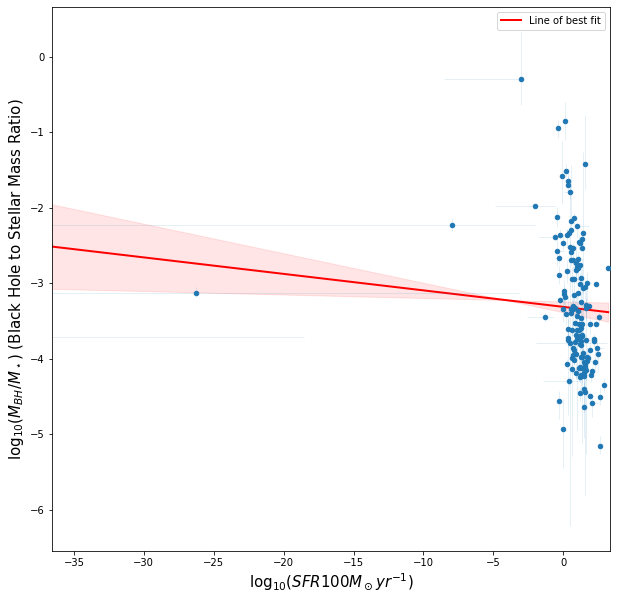

Line of best fit equation: 


<IPython.core.display.Math object>


For plot below: 
Reduced chi squared = 105
Scatter (NMAD of normalised residuals) = 6.901


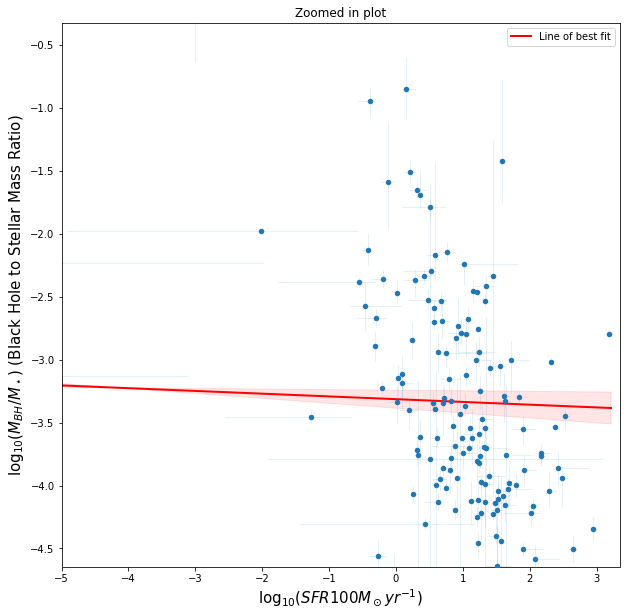

Line of best fit equation: 


<IPython.core.display.Math object>



For plot below: 
Reduced chi squared = 0.064
Scatter (NMAD of normalised residuals) = 0.083


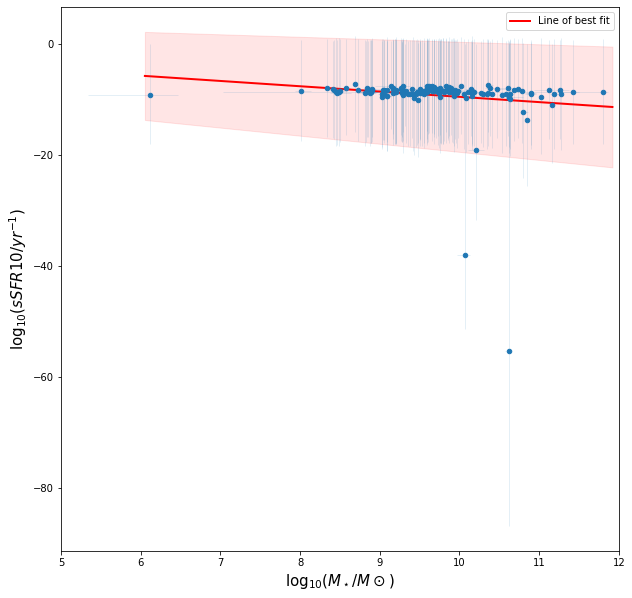

Line of best fit equation: 


<IPython.core.display.Math object>


For plot below: 
Reduced chi squared = 0.064
Scatter (NMAD of normalised residuals) = 0.083


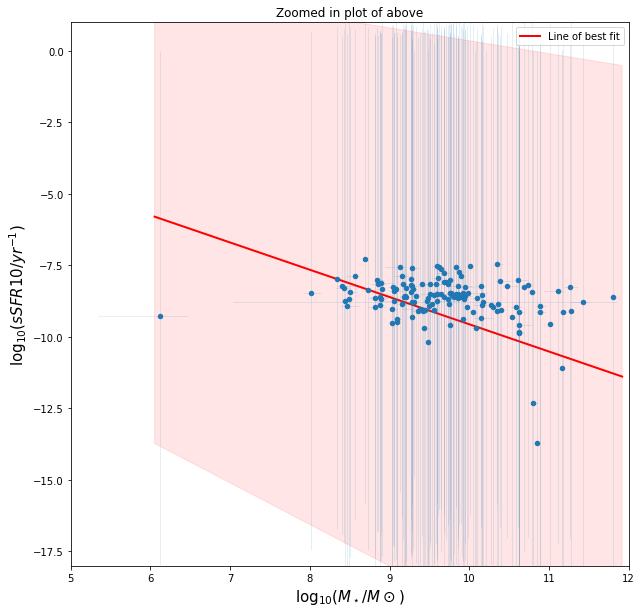


For plot below: 
Reduced chi squared = 0.0145
Scatter (NMAD of normalised residuals) = 0.060


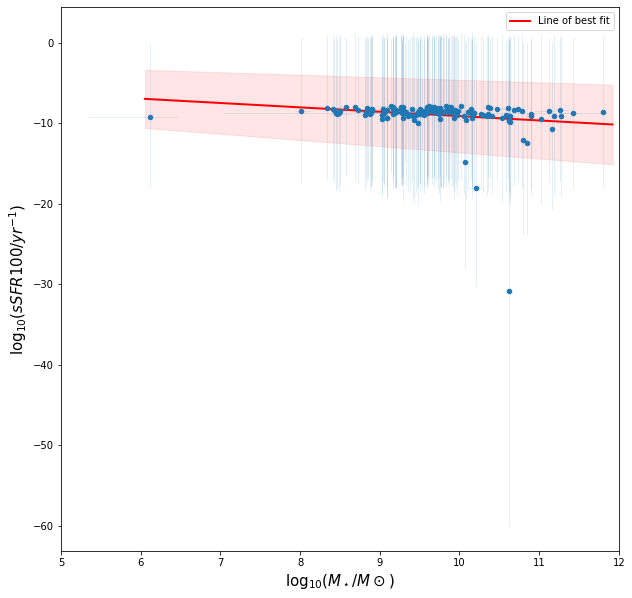

Line of best fit equation: 


<IPython.core.display.Math object>


For plot below: 
Reduced chi squared = 0.0145
Scatter (NMAD of normalised residuals) = 0.060


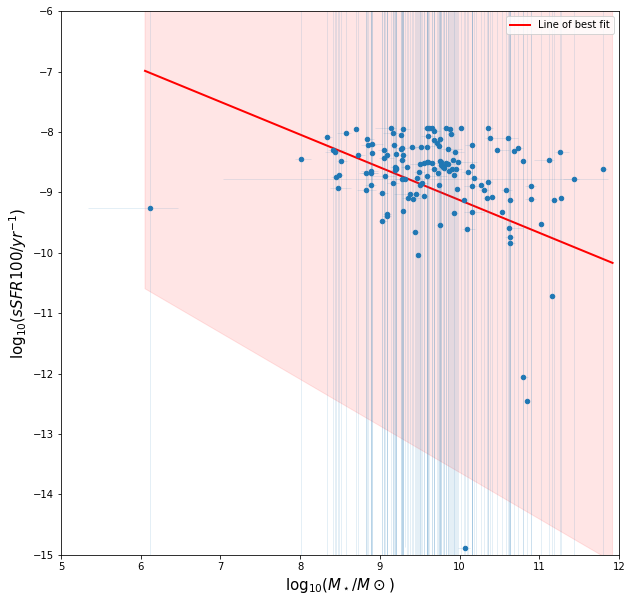


Plot of black hole mass against stellar mass from SED fit of stellar and AGN component

For plot below: 
Reduced chi squared = 7.96e+04
Scatter (NMAD of normalised residuals) = 8.855


/usr/local/anaconda-python-3.6/lib/python3.6/site-packages/ipykernel_launcher.py:26: RuntimeWarning: invalid value encountered in log10


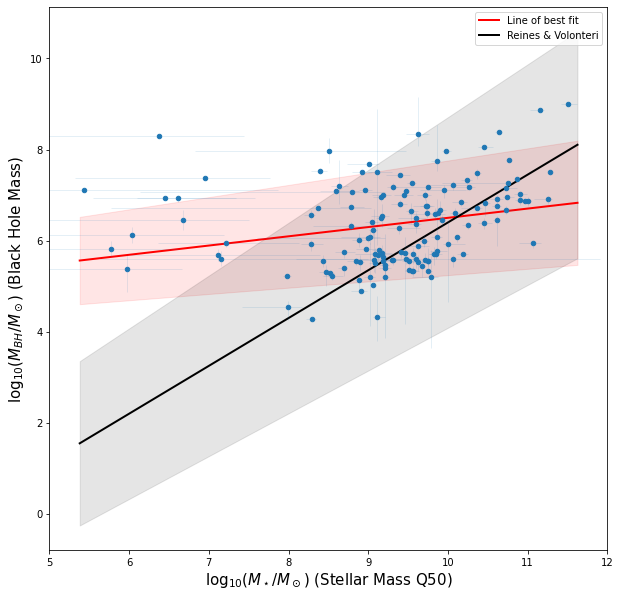

Line of best fit equation: 


<IPython.core.display.Math object>


Reines & Volonteri equation: 


<IPython.core.display.Math object>


For plot below: 
Reduced chi squared = 95.8
Scatter (NMAD of normalised residuals) = 5.953


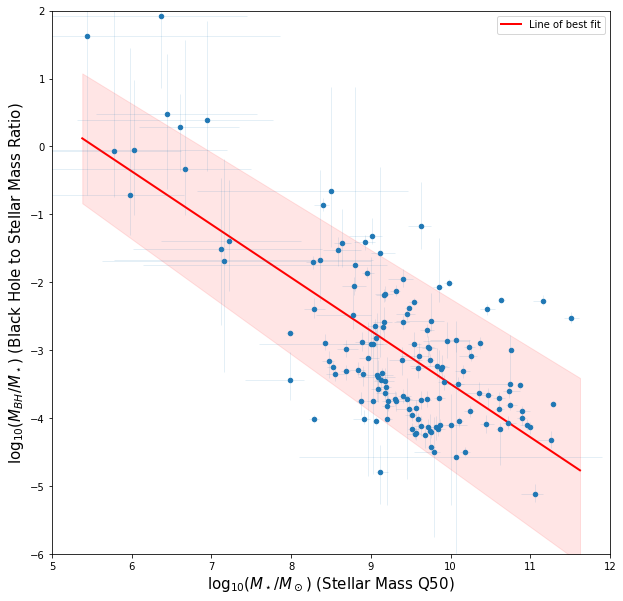

Line of best fit equation: 


<IPython.core.display.Math object>


For plot below: 
Reduced chi squared = 75.8
Scatter (NMAD of normalised residuals) = 7.421


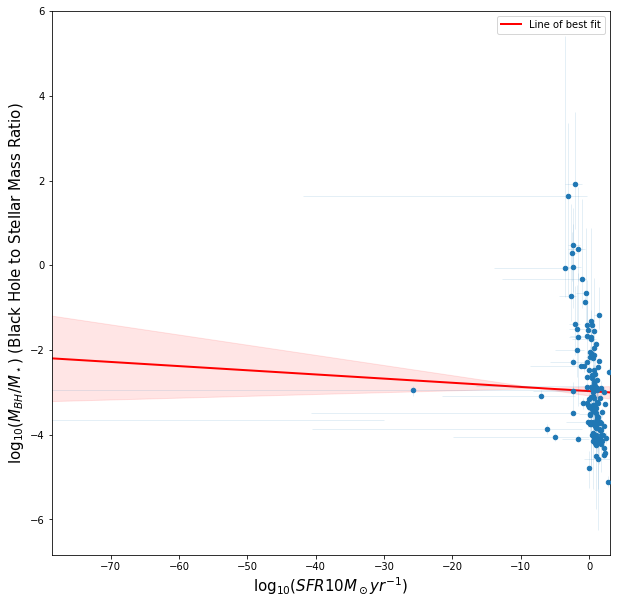

Line of best fit equation: 


<IPython.core.display.Math object>


For plot below: 
Reduced chi squared = 75.8
Scatter (NMAD of normalised residuals) = 7.421


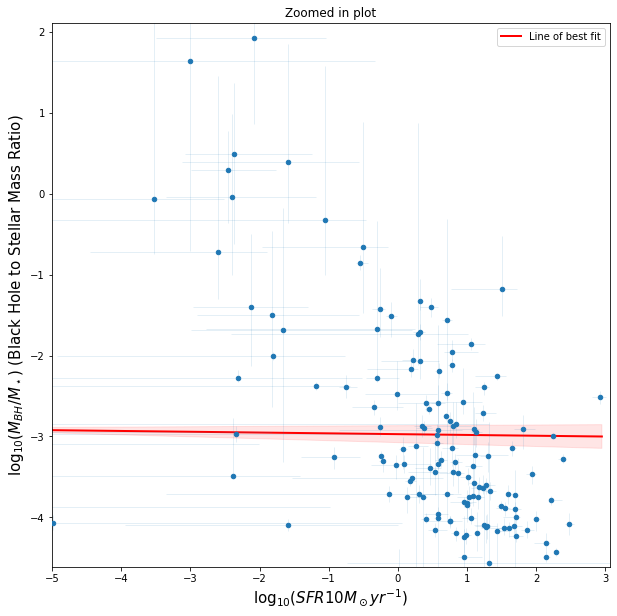

Line of best fit equation: 


<IPython.core.display.Math object>


For plot below: 
Reduced chi squared = 75.9
Scatter (NMAD of normalised residuals) = 7.409


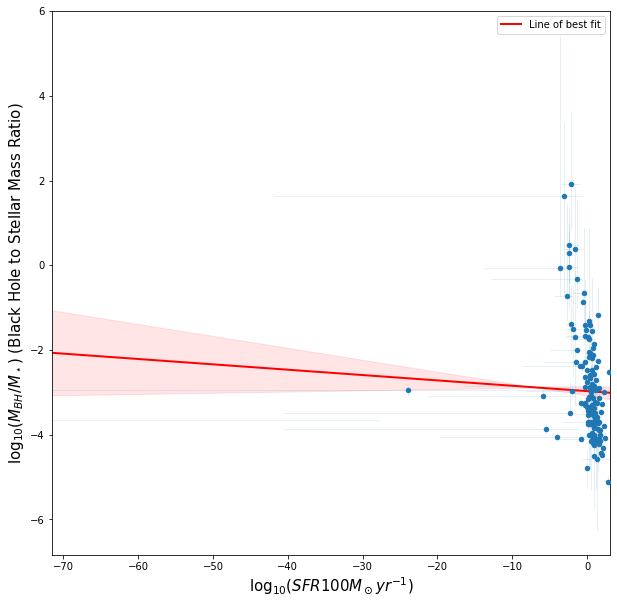

Line of best fit equation: 


<IPython.core.display.Math object>


For plot below: 
Reduced chi squared = 75.9
Scatter (NMAD of normalised residuals) = 7.409


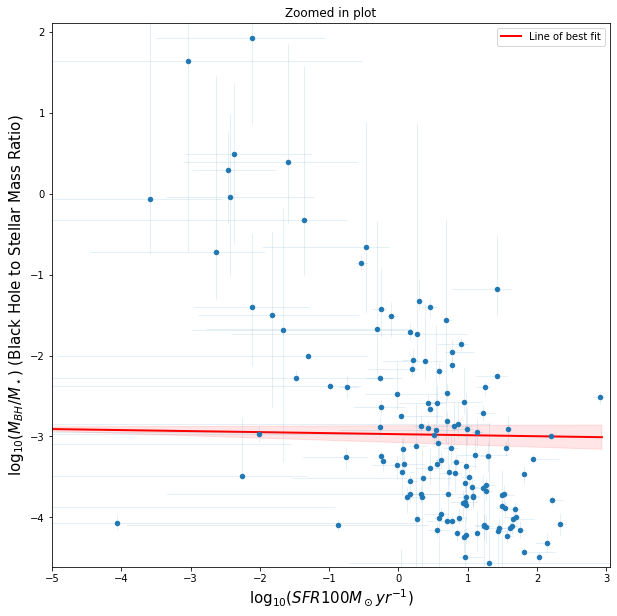

Line of best fit equation: 


<IPython.core.display.Math object>



For plot below: 
Reduced chi squared = 0.0555
Scatter (NMAD of normalised residuals) = 0.084


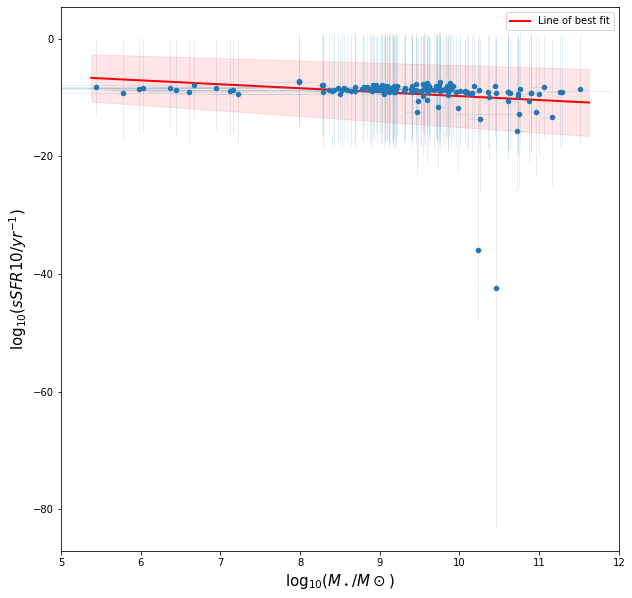

Line of best fit equation: 


<IPython.core.display.Math object>


For plot below: 
Reduced chi squared = 0.0555
Scatter (NMAD of normalised residuals) = 0.084


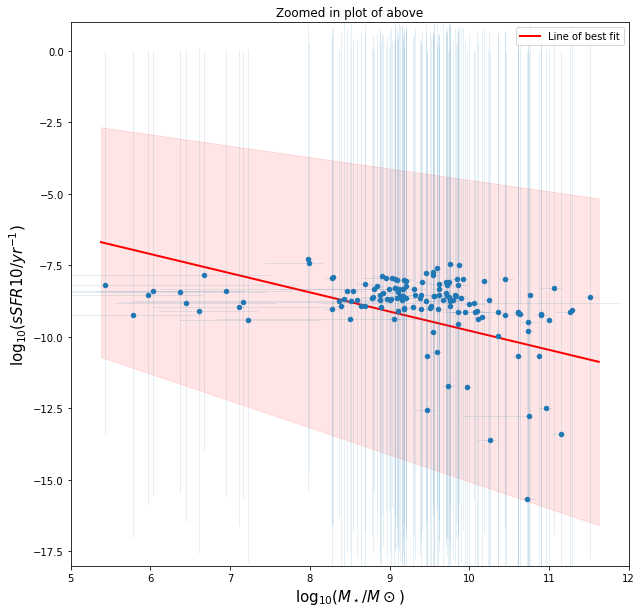


For plot below: 
Reduced chi squared = 0.0471
Scatter (NMAD of normalised residuals) = 0.073


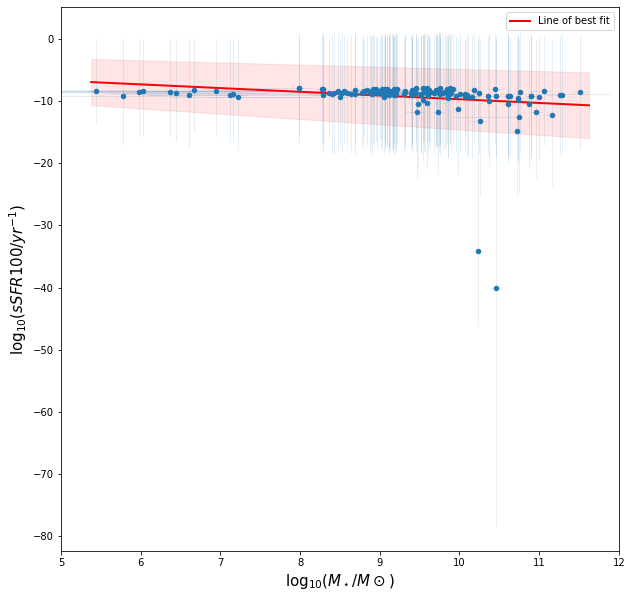

Line of best fit equation: 


<IPython.core.display.Math object>


For plot below: 
Reduced chi squared = 0.0471
Scatter (NMAD of normalised residuals) = 0.073


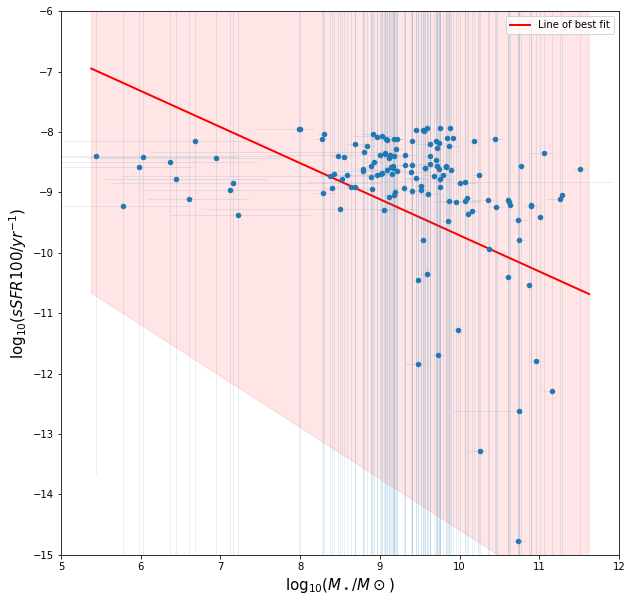

No handles with labels found to put in legend.



For plot below: 
Reduced chi squared = 7.37e+06
Scatter (NMAD of normalised residuals) = 3.195


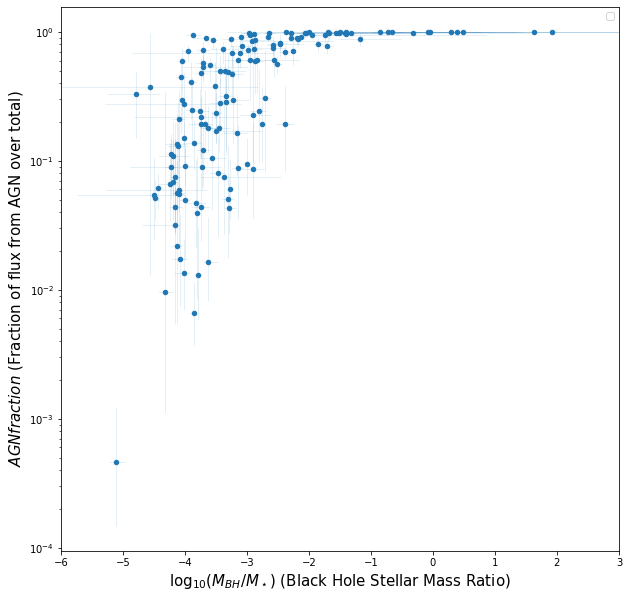

Line of best fit equation: 


<IPython.core.display.Math object>


For plot below: 
Reduced chi squared = 3.11e+03
Scatter (NMAD of normalised residuals) = 2.343


/usr/local/anaconda-python-3.6/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in log10
  from ipykernel import kernelapp as app


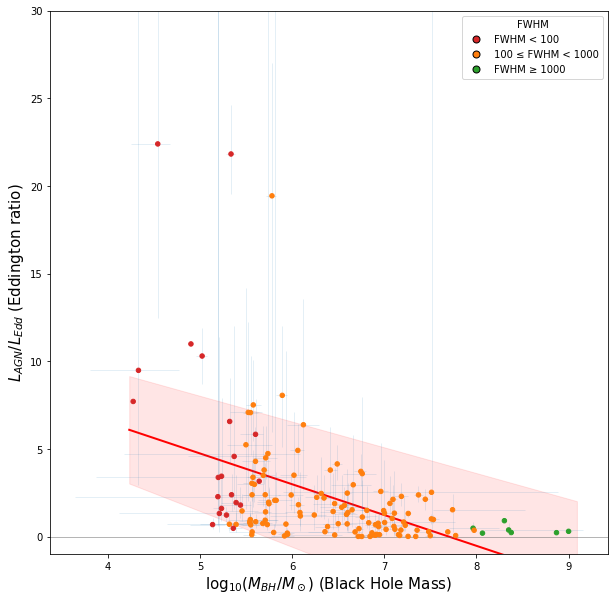

Line of best fit equation: 


<IPython.core.display.Math object>

In [405]:
if __name__ == "__main__":
    
    stellar_only_table = open_csv_table("/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_astro_cat.csv")
    # Contains posterior data from stellar only fit as well as fitted photometry (anything with AGN in the colname has zeros for consistency)

    stellar_AGN_Lbol_prior_table = open_csv_table("/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_fritz_lbol_prior_astro_cat.csv")
    # Contains posterior data from stellar only fit as well as fitted photometry (anything with AGN in the colname has zeros for consistency)

    # stellar_AGN_photom = open_csv_table("/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_fritz_fit_photom.csv")
    
    galaxy_table = open_fits_table("/nvme/scratch/work/alberttg/Summer_project/Ha_and_NII_broad_line_data.fits")
    galaxy_table.rename_column("SURVEY_ID", "ID")
    #-----------------------------------------------------------------------------------------------------------------------
    
    combined_SED_tables = join(
        stellar_only_table,
        stellar_AGN_Lbol_prior_table,
        keys="ID",
        table_names=["stellar", "AGN"],
        uniq_col_name="{col_name}_{table_name}",
    )
    
    plot_stellar_masses(combined_SED_tables)
    
    stellar_only_and_galaxy_table = join(
        stellar_only_table,
        galaxy_table,
        keys="ID"
    )

    stellar_AGN_and_galaxy_table = join(
        stellar_AGN_Lbol_prior_table,
        galaxy_table,
        keys="ID"
    )
    
    plot_AGNlum(stellar_only_table, stellar_AGN_Lbol_prior_table, galaxy_table)
    # Makes DIC filtered table inside this function, consider making it outside
    #-----------------------------------------------------------------------------------------------------------------------
    print("")
    print("Plot of black hole mass against stellar mass from SED fit of stellar light only")
    bhm_vs_sm_plot(stellar_only_and_galaxy_table)
    stellar_only_and_galaxy_table = bhsmr_plots(stellar_only_and_galaxy_table)
    # Table now has columns for bhsmr and its errors
    print("")
    sSFR_vs_M(stellar_only_table)

    #-----------------------------------------------------------------------------------------------------------------------
    print("")
    print("Plot of black hole mass against stellar mass from SED fit of stellar and AGN component")
    bhm_vs_sm_plot(stellar_AGN_and_galaxy_table)
    stellar_AGN_and_galaxy_table = bhsmr_plots(stellar_AGN_and_galaxy_table)
    # Table now has columns for bhsmr and its errors

    #-----------------------------------------------------------------------------------------------------------------------
    print("")
    sSFR10, sSFR10_upper_err, sSFR10_lower_err, sSFR100, sSFR100_upper_err, sSFR100_lower_err = sSFR_vs_M(stellar_AGN_Lbol_prior_table)

    AGNfrac_vs_bhsmr(stellar_AGN_and_galaxy_table)

    edd_ratio_vs_bh_m(galaxy_table)
    